# 2. Event-Driven Market Reaction

Goal: test whether major AI paper dates are followed by abnormal BOTZ volume reactions.

## 2.0 Setup and Libraries

This cell imports all required libraries used throughout the notebook.

In [1]:
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)

## 2.1 Data and Event Set

How to read this section:
- `PAPER_EVENTS` is the event list used in all later analyses.
- Dates are publication/report dates and will be mapped to trading days when needed.

In [2]:
PAPER_EVENTS = [
    {'name': 'Grad-CAM', 'date': '2016-10-07'},
    {'name': 'GCN', 'date': '2017-03-26'},
    {'name': 'Transformer (Attention Is All You Need)', 'date': '2017-06-12'},
    {'name': 'BERT', 'date': '2018-10-11'},
    {'name': 'EfficientNet', 'date': '2019-05-28'},
    {'name': 'GPT-3', 'date': '2020-05-28'},
    {'name': 'ViT', 'date': '2020-10-22'},
    {'name': 'CLIP', 'date': '2021-02-26'},
    {'name': 'LoRA', 'date': '2021-06-17'},
    {'name': 'AlphaFold 2', 'date': '2021-07-15'},
    {'name': 'GPT-4 Technical Report', 'date': '2023-03-15'},
    {'name': 'AlphaFold 3', 'date': '2024-05-08'},
]

ESTIMATION_LOOKBACK = 120
ESTIMATION_GAP = 10
EVENT_WINDOW = (-1, 1)  # t-1, t, t+1
TICKERS = ['BOTZ', 'QQQ']

## 2.2 Method (Quick)

1. Baseline window: `t-120` to `t-10`
2. Event window: `[t-1, t, t+1]`
3. Relative volume: `BOTZ/QQQ`
4. Compute SCAV and p-values
5. Apply BH-FDR correction

### Mini Glossary (1-line)

- **SCAV**: Standardized score of cumulative abnormal volume in the event window.
- **BH-FDR**: Multiple-testing correction to reduce false positives across many events.
- **One-sided p-value**: Tests only the positive-reaction direction (`> 0`).
- **Fail to reject H0**: Not enough evidence against H0; this does **not** prove H0 is true.

## 2.3 Reproducible Helpers

Single pipeline functions for download, trading-day mapping, and event metrics.

In [3]:
def download_volume_data(start_date: str, end_date: str) -> pd.DataFrame:
    data = yf.download(TICKERS, start=start_date, end=end_date, progress=False, auto_adjust=False)
    if data.empty or 'Volume' not in data.columns.get_level_values(0):
        raise ValueError('Could not fetch volume data for BOTZ/QQQ.')

    volume = data['Volume'].copy()
    volume = volume.rename(columns={'BOTZ': 'botz_volume', 'QQQ': 'qqq_volume'})
    volume = volume.dropna(subset=['botz_volume', 'qqq_volume'])
    volume = volume[volume['qqq_volume'] > 0]
    volume['ratio'] = volume['botz_volume'] / volume['qqq_volume']
    return volume


def first_trading_day_on_or_after(index: pd.DatetimeIndex, event_date: pd.Timestamp):
    valid_days = index[index >= event_date]
    return valid_days[0] if len(valid_days) > 0 else None


def compute_event_metrics(volume_df: pd.DataFrame, event_name: str, event_date: str) -> dict | None:
    requested_date = pd.to_datetime(event_date)
    actual_date = first_trading_day_on_or_after(volume_df.index, requested_date)
    if actual_date is None:
        return None

    event_idx = volume_df.index.get_loc(actual_date)
    left, right = EVENT_WINDOW

    est_start = event_idx - ESTIMATION_LOOKBACK
    est_end = event_idx - ESTIMATION_GAP
    win_start = event_idx + left
    win_end = event_idx + right + 1

    if est_start < 0 or est_end <= est_start or win_start < 0 or win_end > len(volume_df):
        return None

    est_series = volume_df['ratio'].iloc[est_start:est_end]
    event_series = volume_df['ratio'].iloc[win_start:win_end]

    est_mean = est_series.mean()
    est_std = est_series.std(ddof=1)
    if not np.isfinite(est_std) or est_std == 0:
        return None

    z_scores = (event_series - est_mean) / est_std
    scav = z_scores.sum() / np.sqrt(len(z_scores))
    p_value = 1 - stats.norm.cdf(scav)  # one-sided: positive reaction

    abnormal_pct = ((event_series.mean() - est_mean) / est_mean) * 100

    return {
        'event': event_name,
        'requested_date': requested_date.date(),
        'actual_trading_date': actual_date.date(),
        'estimation_mean_ratio': est_mean,
        'event_mean_ratio': event_series.mean(),
        'abnormal_volume_pct': abnormal_pct,
        'scav': scav,
        'event_p_value': p_value,
    }

## 2.4 Main Event Analysis

How to read this table:
- `Abnormal Volume %` > 0 means stronger-than-baseline BOTZ reaction.
- `Reaction Level` gives a quick classroom label (Low/Medium/High).
- This is the **main event table** used in the notebook.

In [4]:
analysis_start = (pd.to_datetime(min(e['date'] for e in PAPER_EVENTS)) - pd.Timedelta(days=260)).strftime('%Y-%m-%d')
analysis_end = (pd.to_datetime(max(e['date'] for e in PAPER_EVENTS)) + pd.Timedelta(days=20)).strftime('%Y-%m-%d')

volume_df = download_volume_data(analysis_start, analysis_end)

records = []
for event in PAPER_EVENTS:
    result = compute_event_metrics(volume_df, event['name'], event['date'])
    if result is not None:
        records.append(result)

results_df = pd.DataFrame(records).sort_values('actual_trading_date').reset_index(drop=True)

# Simple student-friendly table for Section 2.4
simple_24 = results_df[['event', 'actual_trading_date', 'abnormal_volume_pct']].copy()
simple_24 = simple_24.rename(columns={
    'event': 'Event',
    'actual_trading_date': 'Trading Date',
    'abnormal_volume_pct': 'Abnormal Volume %'
})

simple_24['Abnormal Volume %'] = simple_24['Abnormal Volume %'].round(2)

# Easy label for quick interpretation
def reaction_label(x):
    if x >= 15:
        return 'High'
    if x >= 5:
        return 'Medium'
    return 'Low'

simple_24['Reaction Level'] = simple_24['Abnormal Volume %'].apply(reaction_label)
simple_24 = simple_24.sort_values('Abnormal Volume %', ascending=False).reset_index(drop=True)

simple_24

,Event,Trading Date,Abnormal Volume %,Reaction Level
0,GCN,2017-03-27,422.03,High
1,GPT-3,2020-05-28,72.59,High
2,ViT,2020-10-22,32.45,High
3,EfficientNet,2019-05-28,10.85,Medium
4,GPT-4 Technical Report,2023-03-15,-10.45,Low
5,Transformer (Attention Is All You Need),2017-06-12,-28.95,Low
6,BERT,2018-10-11,-30.32,Low
7,AlphaFold 3,2024-05-08,-37.91,Low
8,AlphaFold 2,2021-07-15,-41.54,Low
9,LoRA,2021-06-17,-53.20,Low


## 2.5 Easy-to-Read Micro Event Charts (Before vs After)

The charts below are designed for quick classroom interpretation:
- top: BOTZ closing price
- bottom: BOTZ trading volume
- red dashed line: event date

Each event is shown in a short window (5 business days before and 10 business days after).

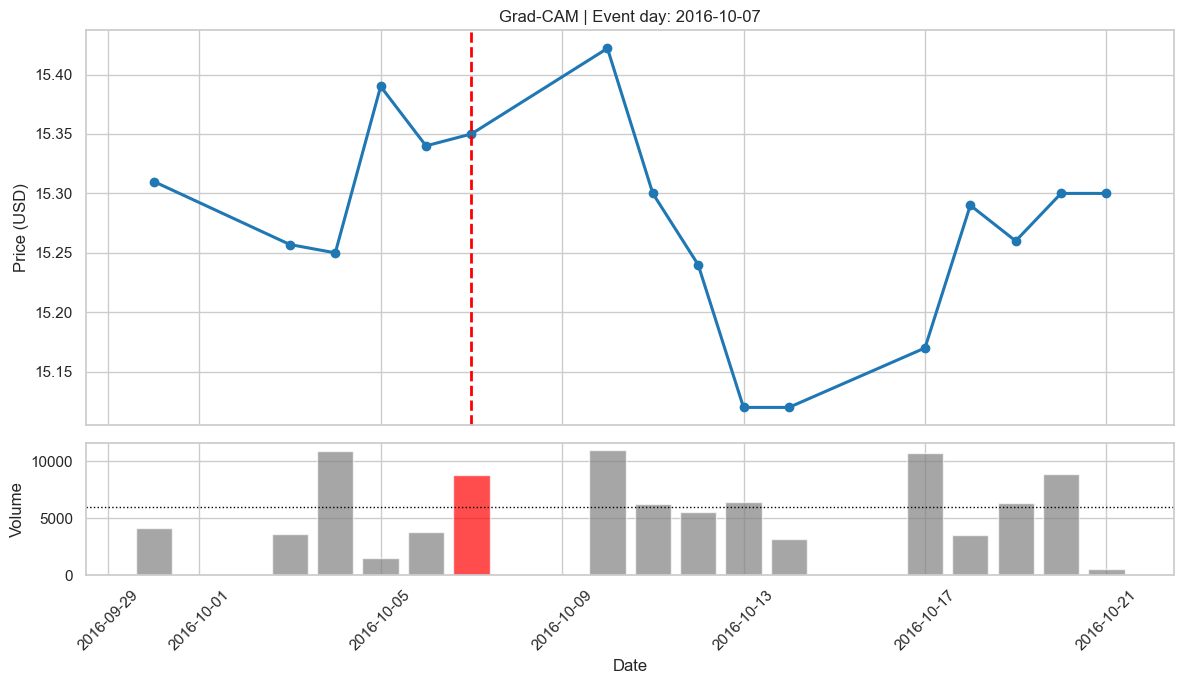

Volume jump vs window average: 48.37%


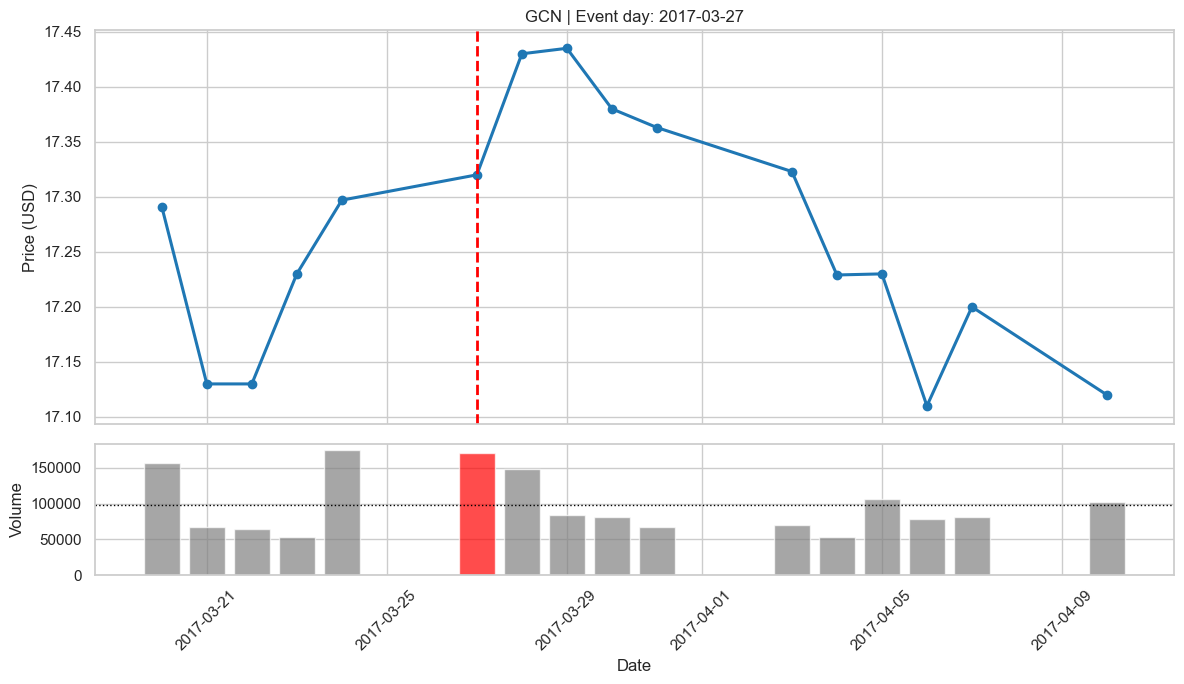

Volume jump vs window average: 75.41%


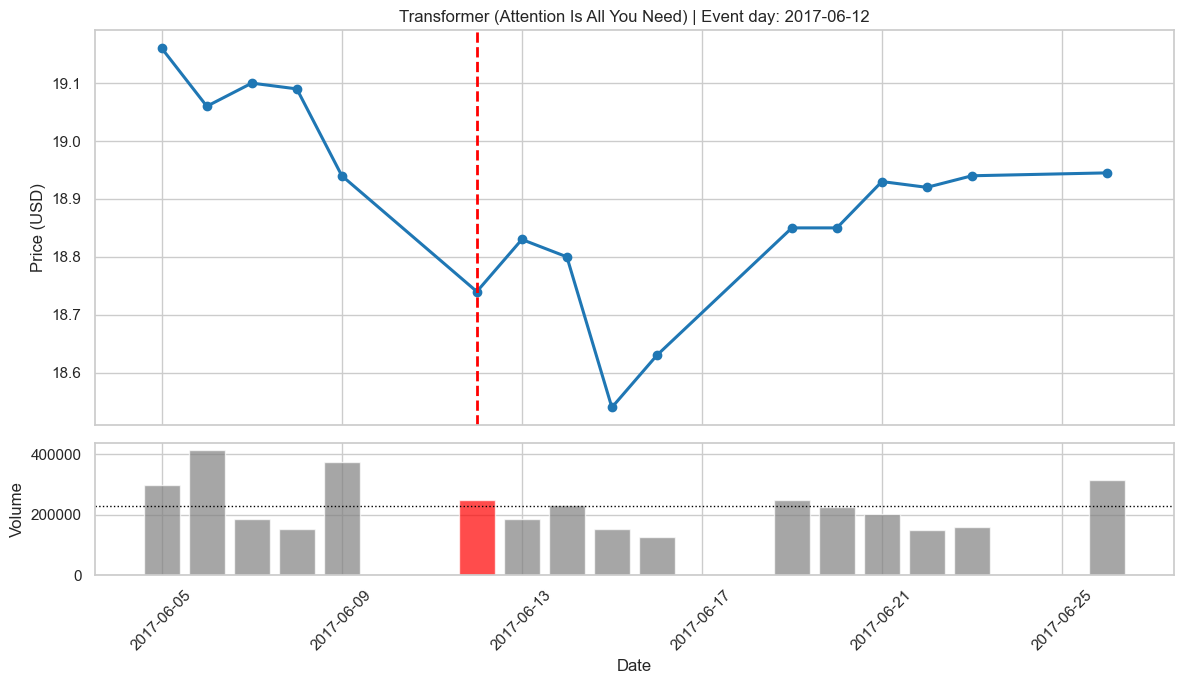

Volume jump vs window average: 7.95%


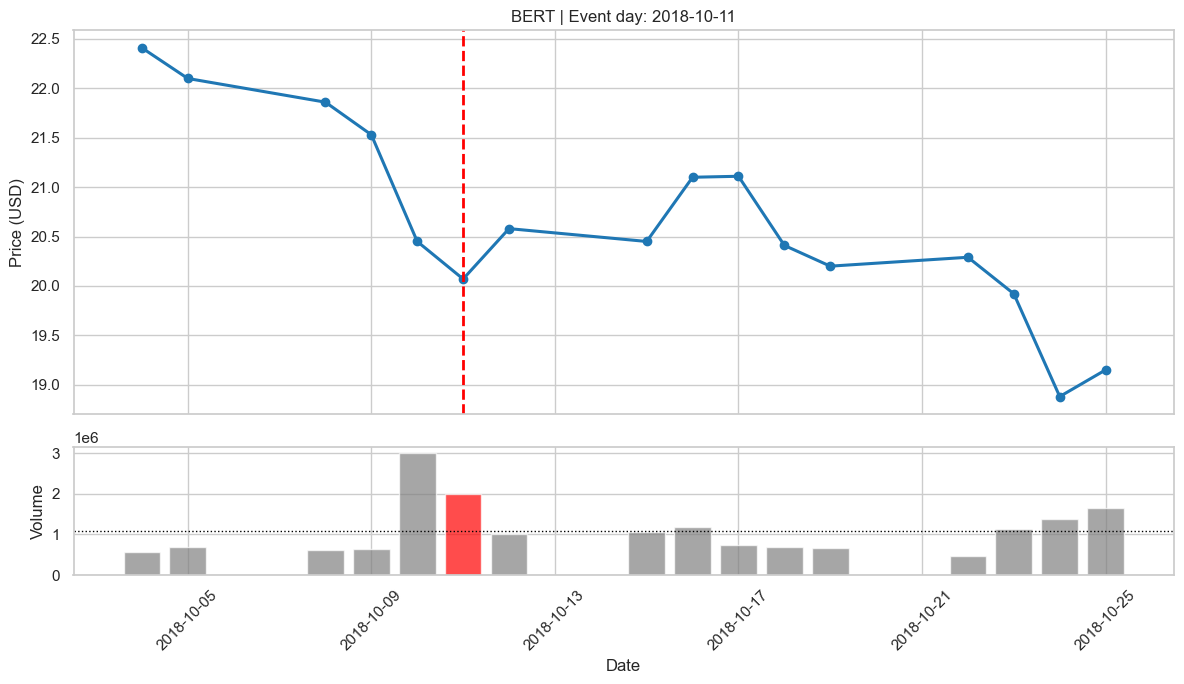

Volume jump vs window average: 82.48%


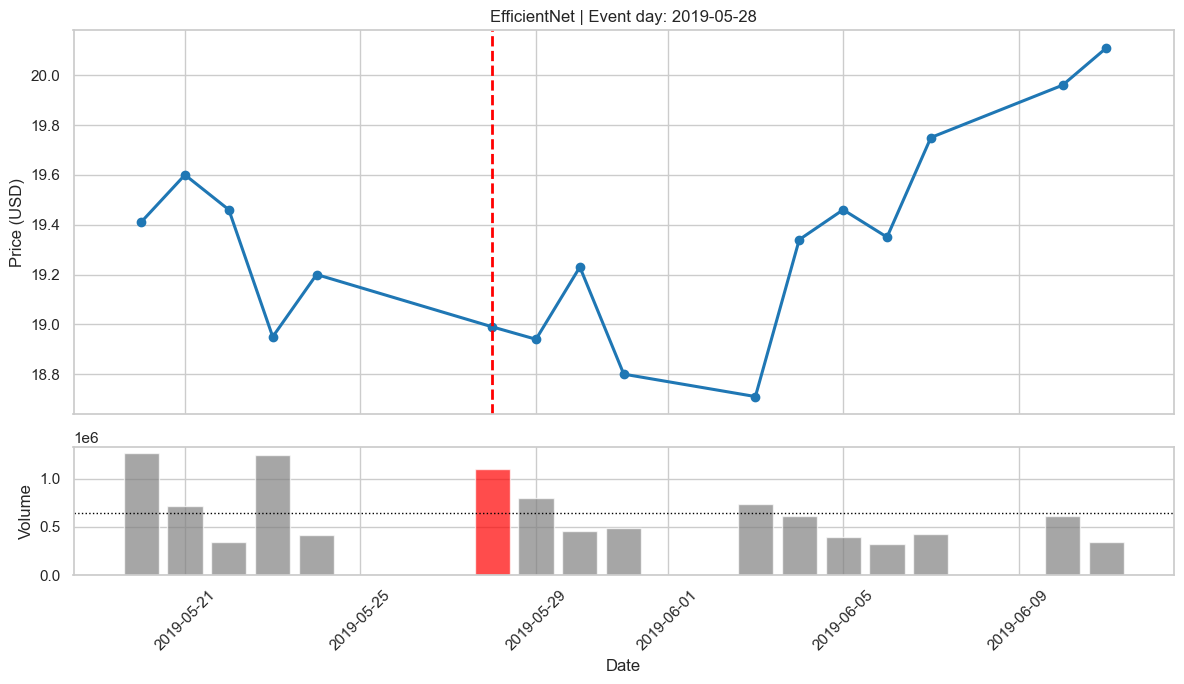

Volume jump vs window average: 71.86%


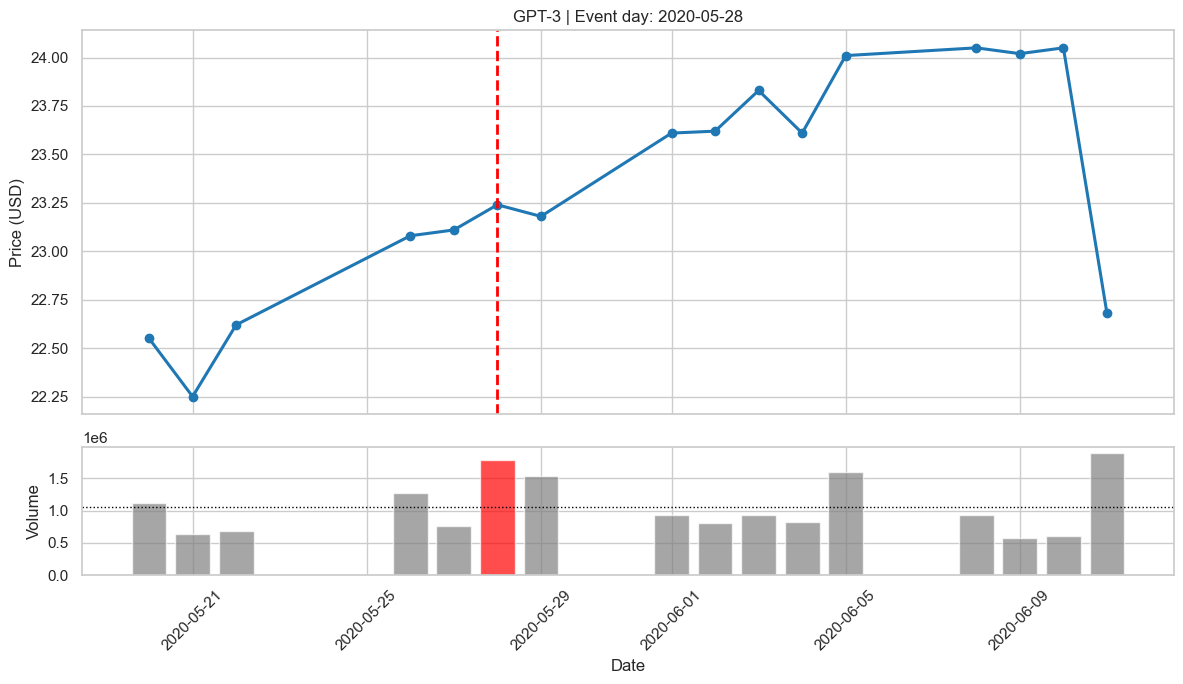

Volume jump vs window average: 68.48%


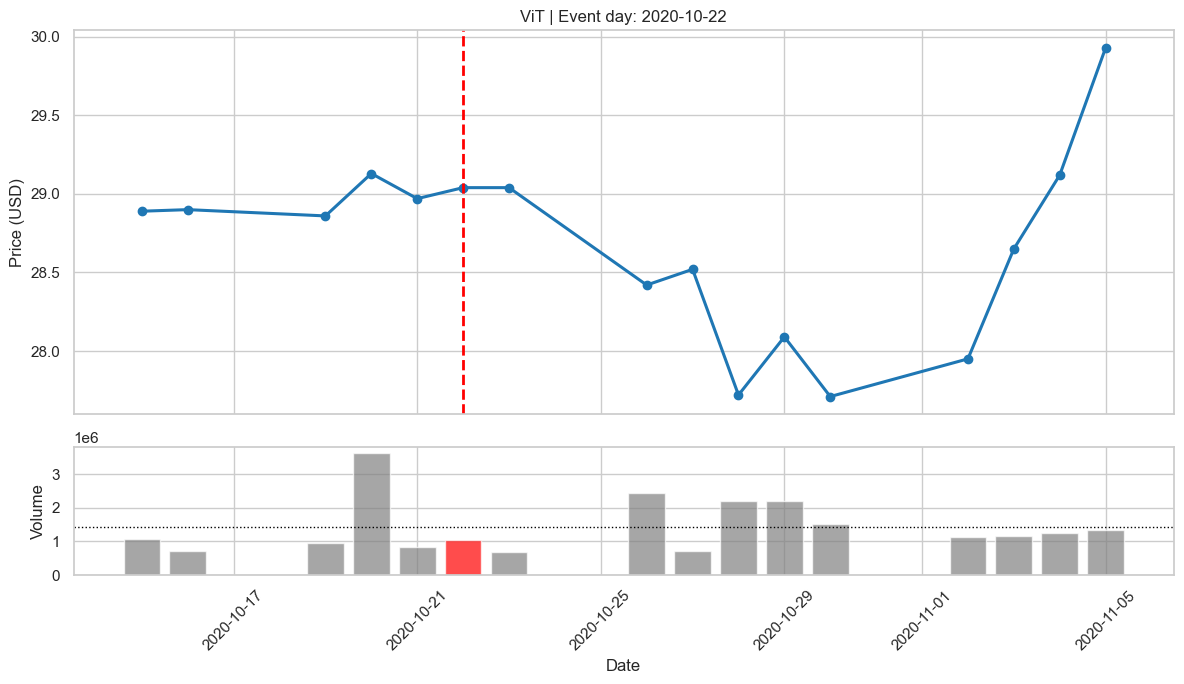

Volume jump vs window average: -27.53%


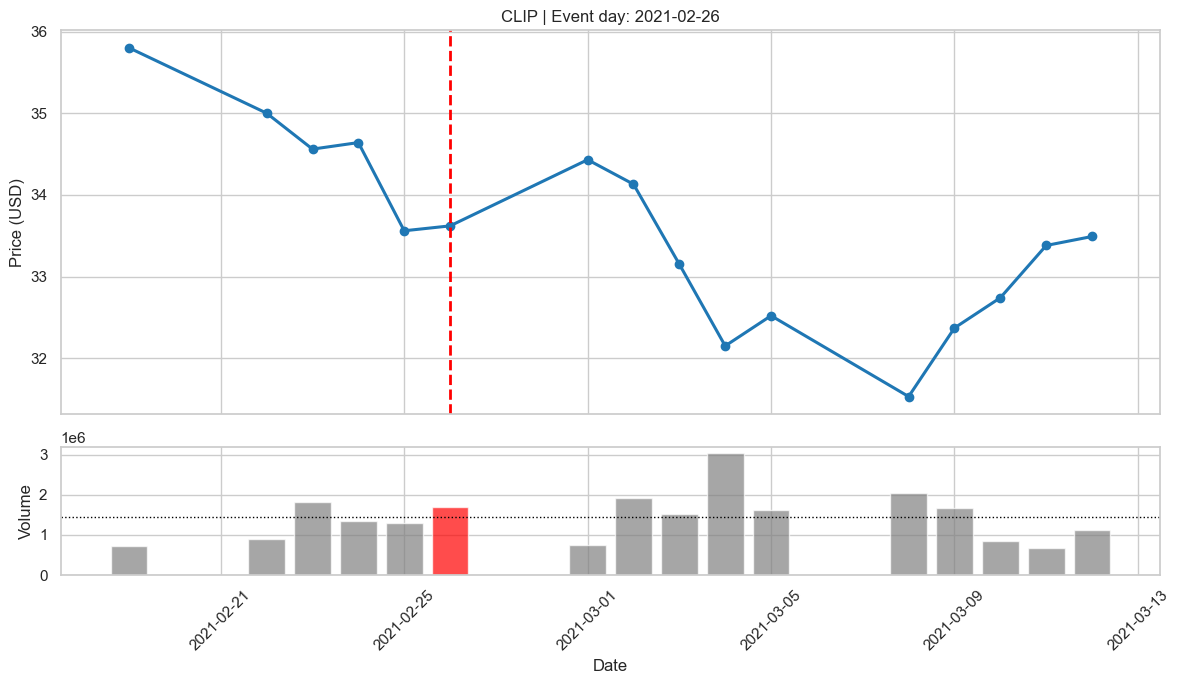

Volume jump vs window average: 18.29%


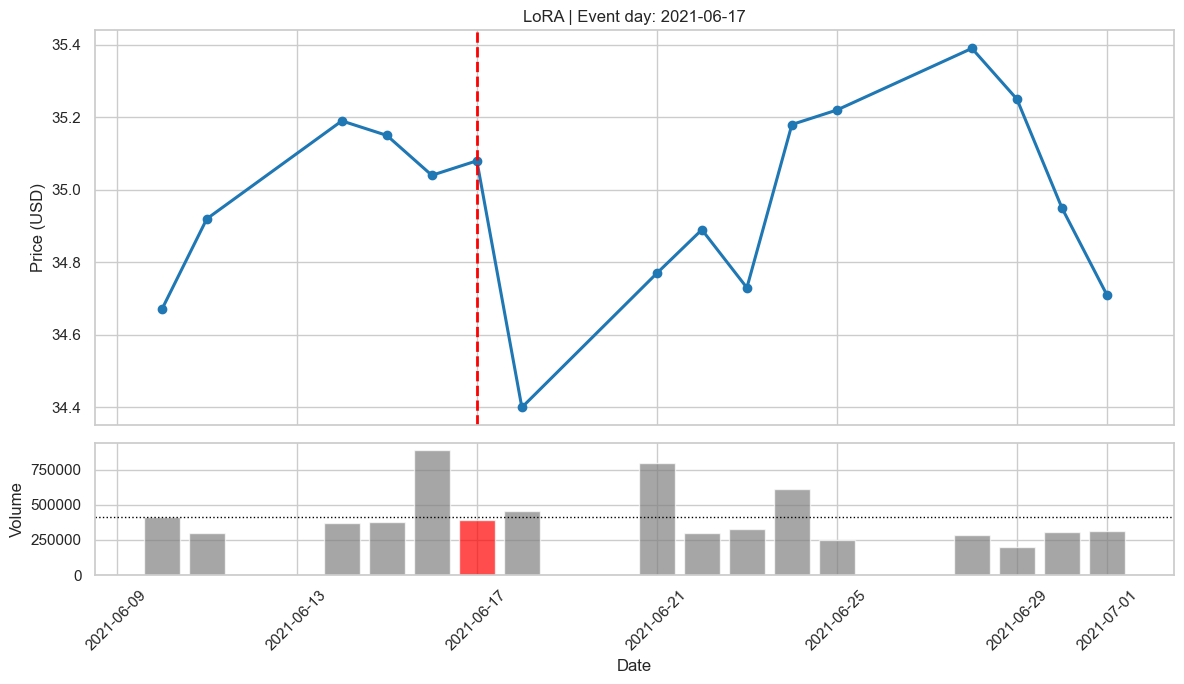

Volume jump vs window average: -4.67%


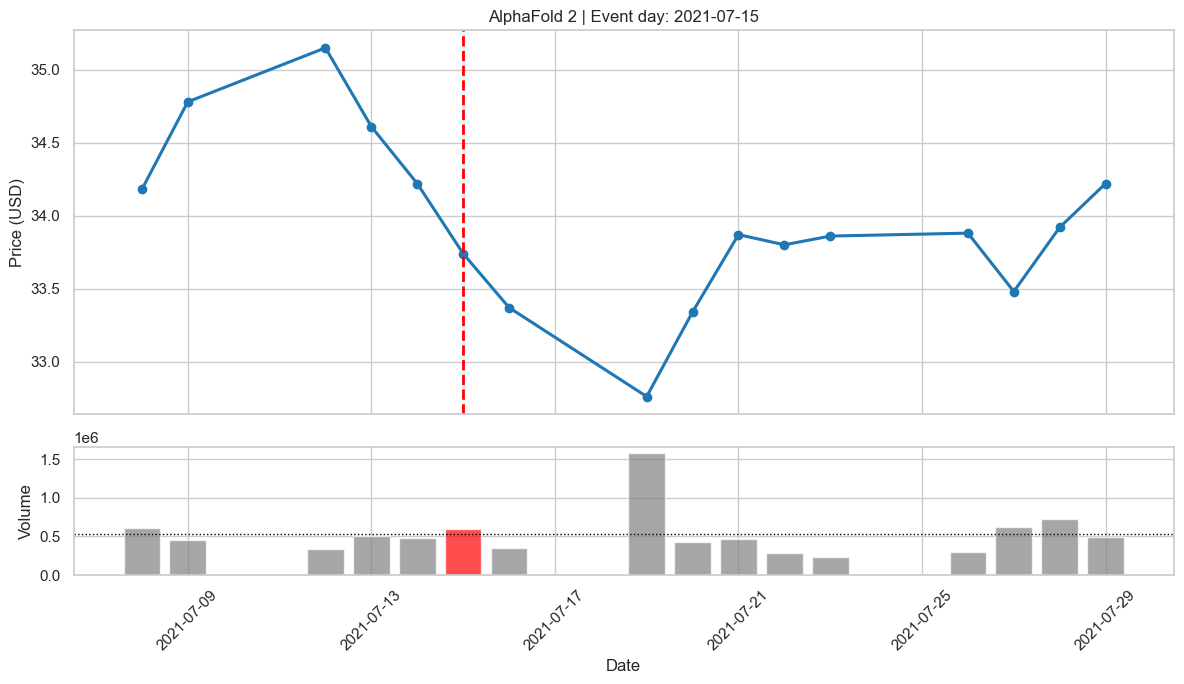

Volume jump vs window average: 12.16%


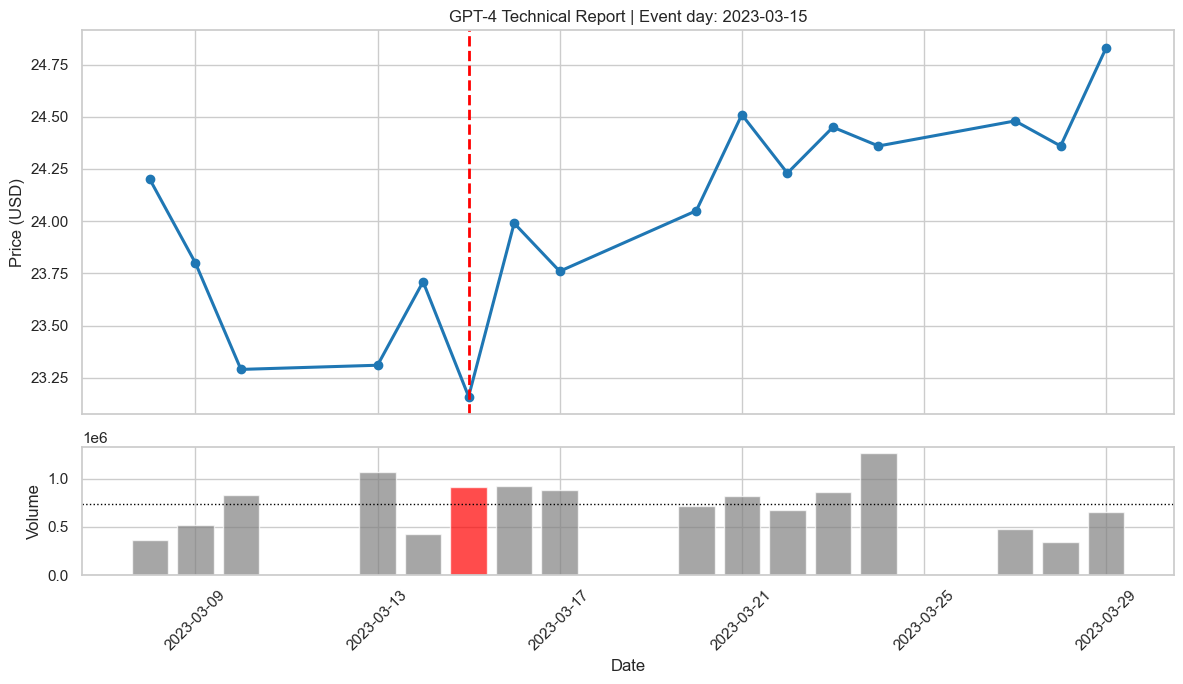

Volume jump vs window average: 23.68%


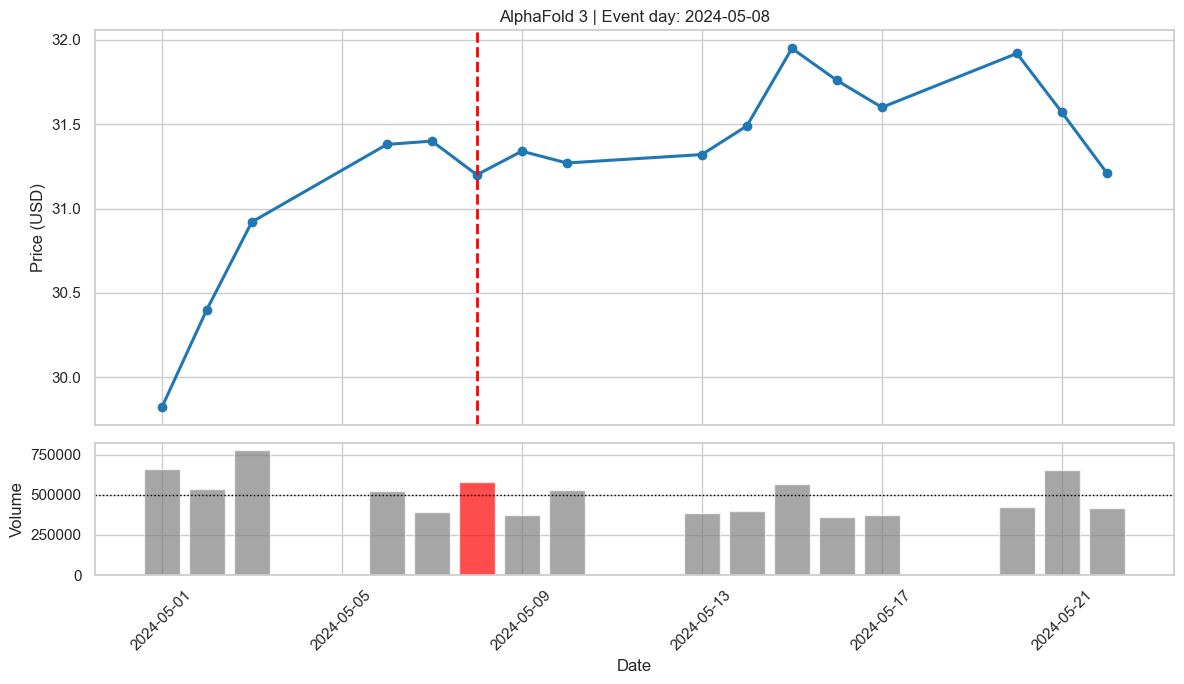

Volume jump vs window average: 16.17%


In [5]:
def plot_micro_event_window(event_name: str, event_date_str: str, pre_days: int = 5, post_days: int = 10):
    event_date = pd.to_datetime(event_date_str)
    start_date = (event_date - pd.Timedelta(days=pre_days * 2)).strftime('%Y-%m-%d')
    end_date = (event_date + pd.Timedelta(days=post_days * 2)).strftime('%Y-%m-%d')

    data = yf.download('BOTZ', start=start_date, end=end_date, progress=False, auto_adjust=False)
    if data.empty:
        print(f'No data for {event_name}')
        return

    if isinstance(data.columns, pd.MultiIndex):
        close = data['Close']['BOTZ'].dropna()
        volume = data['Volume']['BOTZ'].dropna()
    else:
        close = data['Close'].dropna()
        volume = data['Volume'].dropna()

    # Align non-trading event dates to next available trading day
    valid_days = close.index[close.index >= event_date]
    if len(valid_days) == 0:
        print(f'No trading day found for {event_name}')
        return
    actual_event_day = valid_days[0]

    idx = close.index.get_loc(actual_event_day)
    left = max(0, idx - pre_days)
    right = min(len(close), idx + post_days + 1)

    c = close.iloc[left:right]
    v = volume.reindex(c.index)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(c.index, c.values, marker='o', linewidth=2.2, color='#1f77b4')
    ax1.axvline(actual_event_day, color='red', linestyle='--', linewidth=2)
    ax1.set_title(f'{event_name} | Event day: {actual_event_day.date()}')
    ax1.set_ylabel('Price (USD)')

    bar_colors = ['red' if d == actual_event_day else 'gray' for d in c.index]
    ax2.bar(c.index, v.values, color=bar_colors, alpha=0.7)
    ax2.axhline(v.mean(), color='black', linestyle=':', linewidth=1)
    ax2.set_ylabel('Volume')
    ax2.set_xlabel('Date')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    event_vol = float(v.loc[actual_event_day])
    avg_vol = float(v.mean())
    jump_pct = (event_vol / avg_vol - 1) * 100
    print(f'Volume jump vs window average: {jump_pct:.2f}%')

# Plot all events in PAPER_EVENTS (11 total)
for e in PAPER_EVENTS:
    plot_micro_event_window(e['name'], e['date'])

## 2.6 Significance View (BH-Adjusted)

How to read this chart:
- Bars further right indicate stronger evidence.
- Dashed line is the 5% significance threshold after BH adjustment.

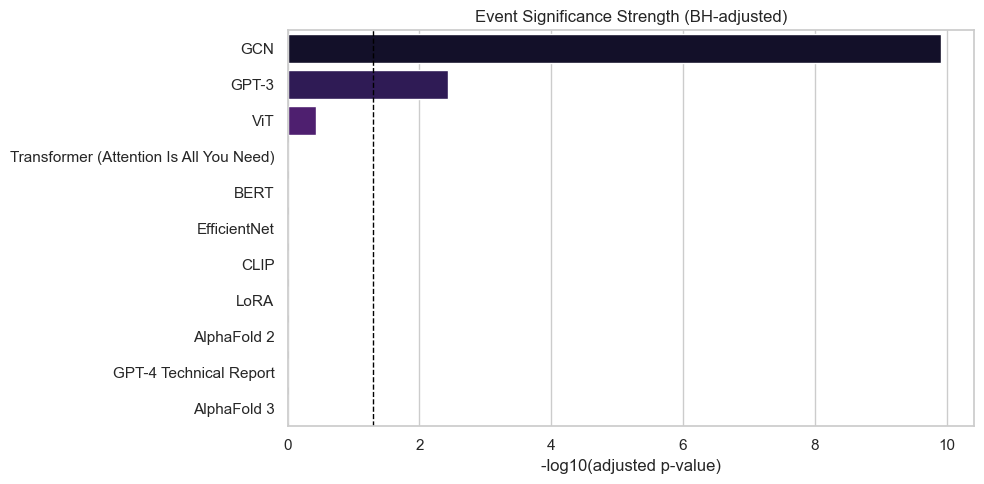

In [6]:
if 'event_p_value_adj_bh' not in results_df.columns:
    _, p_adj_tmp, _, _ = multipletests(results_df['event_p_value'], alpha=0.05, method='fdr_bh')
    results_df['event_p_value_adj_bh'] = p_adj_tmp

plot_df = results_df.copy()
plot_df['neglog10_adj_p'] = -np.log10(np.clip(plot_df['event_p_value_adj_bh'], 1e-12, 1.0))
plot_df = plot_df.sort_values('neglog10_adj_p', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='neglog10_adj_p', y='event', palette='magma')
plt.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1)
plt.title('Event Significance Strength (BH-adjusted)')
plt.xlabel('-log10(adjusted p-value)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 2.7 Bottom Line

- **What we observed:** Several events show positive abnormal volume reactions in BOTZ.
- **What comes next (HT):** Formal causality-oriented testing with stricter assumptions.

## 2.8 Final Hypothesis Decision

### Hypotheses
- **H0:** Average abnormal volume reaction is not positive (`<= 0`).
- **H1:** Average abnormal volume reaction is positive (`> 0`).


**Fail to reject H0 does not prove H0 is true.**

In [7]:
if 'results_df' not in globals() or results_df.empty:
    raise ValueError('results_df is empty. Please run previous analysis cells first.')

alpha = 0.05
abnormal = results_df['abnormal_volume_pct'].dropna().values

wilcoxon_stat, wilcoxon_p_two = stats.wilcoxon(abnormal, zero_method='wilcox', alternative='two-sided')
wilcoxon_p_one = wilcoxon_p_two / 2 if abnormal.mean() > 0 else 1 - wilcoxon_p_two / 2

ttest_stat, ttest_p_one = stats.ttest_1samp(abnormal, popmean=0.0, alternative='greater')

if 'event_p_value_adj_bh' not in results_df.columns:
    _, p_adj_tmp, _, _ = multipletests(results_df['event_p_value'], alpha=alpha, method='fdr_bh')
    results_df['event_p_value_adj_bh'] = p_adj_tmp
bh_sig_count = int((results_df['event_p_value_adj_bh'] < alpha).sum())

def decision_and_comment(pv):
    if pv < alpha:
        return 'Reject H0', 'Evidence supports a positive average reaction.'
    return 'Fail to reject H0', 'Evidence is not strong enough for a positive average reaction.'

w_dec, w_msg = decision_and_comment(wilcoxon_p_one)
t_dec, t_msg = decision_and_comment(ttest_p_one)

final_hypothesis_summary = pd.DataFrame([
    {'Test': 'Wilcoxon (one-sided)', 'p-value': round(float(wilcoxon_p_one), 4), 'Decision': w_dec, 'Interpretation': w_msg},
    {'Test': 'One-sample t-test (one-sided)', 'p-value': round(float(ttest_p_one), 4), 'Decision': t_dec, 'Interpretation': t_msg},
])

print(f'Events analyzed: {len(results_df)} | BH-significant events (5%): {bh_sig_count}')
final_hypothesis_summary

Events analyzed: 11 | BH-significant events (5%): 2


,Test,p-value,Decision,Interpretation
0,Wilcoxon (one-sided),0.3501,Fail to reject H0,Evidence is not strong enough for a positive a...
1,One-sample t-test (one-sided),0.2745,Fail to reject H0,Evidence is not strong enough for a positive a...


## 2.9 Limitations

### 1. Small Sample Size (n = 12)
The analysis is based on 12 events, which results in low statistical power for both the Wilcoxon signed-rank test and the one-sample t-test. A "fail to reject H0" outcome in this setting does not reliably confirm the absence of an effect — it may simply reflect insufficient data to detect one. A larger and more systematically constructed event set would be needed to draw stronger conclusions.

### 2. Event Date Ambiguity
For several papers in the event list, the arXiv preprint date, the conference presentation date, and the date of broader media coverage differ meaningfully. Since market participants react to *when they learn about* a paper — not necessarily its formal publication date — the event windows used here may not align with the actual information arrival. This misalignment could attenuate or distort the measured abnormal volume signal.

### 3. Event Contamination
Several events cluster in the 2021–2023 period, resulting in cases where one event's estimation window overlaps with another event's event window. When the baseline is estimated over a period that already contains an abnormal reaction, the baseline mean is inflated and the computed abnormal volume is understated. A minimum inter-event spacing filter was not applied in this analysis, which limits the reliability of individual event metrics in high-density periods.